# Genetic Algorithms 

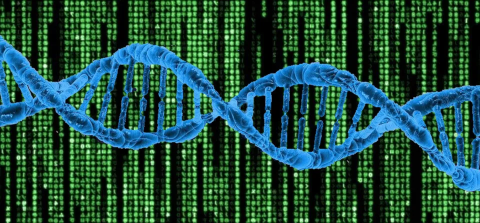

**GAs are stochastic, population-based optimisation methods inspired by the process of natural (Darwinian) evolution.** They explore solution spaces via artificially simulating: 
- Multi-modal, population-based search
- Fitness biased selection & elitist survival (survival of the fittest) 
- Reproduction (randomised crossover of solution chromosomes)
- Random genetic mutations 


### Characteristics of GAs
- <span style="color:#66AADE">Robust, general purpose metaheuristics that can search multiple regions of parameter space simultaneously</span>
- <span style="color:#66AADE">Non-exact stochastic method, but good global optimisers (can often find good approximations to the global optimum)</span>
- <span style="color:#66AADE">Can handle highly non-linear, non-convex, multimodal optimization problems</span>
- <span style="color:#66AADE">Can handle mixture of integer and decimal decision variables</span>
- <span style="color:#66AADE">Relatively few parameters compared to many other metaheuristics (population size, mutation rate, penalty factors)</span>
- <span style="color:#66AADE">Can handle constraints via penalty terms or constraint-aware selection</span>
- <span style="color:#66AADE">Suitable for "black-box" / derivative-free problems and multiobjective optimisation (with some modifications)</span>
- <span style="color:#F2667F">Not suitable for expensive optimisation (where your objective function is expensive to calculate - e.g. simulation-based optimisation)</span>
- <span style="color:#F2667F">Might not be suitable when there are many constraints or feasible solutions are rare / hard to locate</span>
- <span style="color:#F2667F">Can suffer from problems like premature convergence / becoming trapped in local optimum / loss of diversity (especially if poorly tuned or selection pressure too high)</span>
- There has been a LOT of research on GAs and there are many variants that seek to address shortfalls of the original algorithm variants, such as diversity enhancing selection mechanisms.

### GA Problem Encoding

Solutions are encoded as a **genomic representation of the decision variables** (called a _chromosome_ or _genotype_), which undergo operations similar to what happens to animal reproductive cells in nature. Each decision variable is a **gene.** The genotype is decoded into a phenotype, which is the physical (or modelled) manifestation of the individual whose performance in its environment is governed by fitness objective functions and constraint functions.

Although GAs can handle virtually any problem structure, the chromosome structure is important and must be compatible with the chosen crossover and mutation operators. It is sometimes possible to encode certain constraints into the chromosome structure itself to avoid it ever being infeasible wrt those constraints (example being a whole number decision variable with 4 options being encoded as a length 2 binary string). Sometimes infeasible children can be treated with a repair operator to make the solution feasible. Local search that uses derivative approximations can also be used. 

## Genetic Algorithm Glossary

**Solution Chromosome:** 
The encoding of a solution (decision variables) - traditionally a binary string was used, but real numbers are better for real-valued variables

**Fitness Evaluation**
The decoding of the population genotypes to determine the fitness of solutions according to objective function/s

**Biased Selection:** 
Solutions with higher fitness have a higher probability of selection for simulated reproduction. Roulette wheel, rank-based and tournament selection are popular mechanisms. Binary tournaments are less prone to premature convergence.

**Solution Reproduction:**
Parent solutions (typically two) are randomly combined to be produce (typically two) child solutions.

**Crossover Operator:** The mechanism used to combine genetic information from multiple parent solutions to form a child solution. Typical examples include uniform crossover, single- and two-point crossover, SBX crossover for real numbers

**Mutation Operator:** Method of introducing random mutations into the population with a small chance - useful to escape local optima.

**Elitist Survival:** Selection of the N best solutions (incl. parents) to survive to the next generation. Often simply the top $N$ out of $2N$ solutions.

**Constraint Penalty Function:** Add a constraint violation penalty to the solution’s fitness (minimisation). Penalty factor should be scaled to the magnitude of the fitness to facilitate navigation along the boundaries of the feasible region.


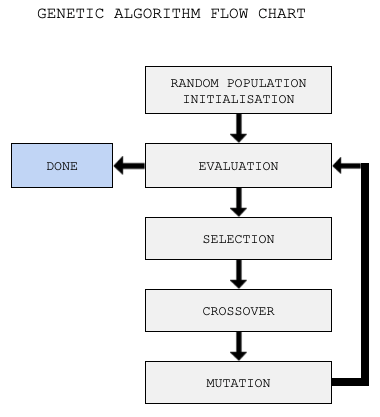

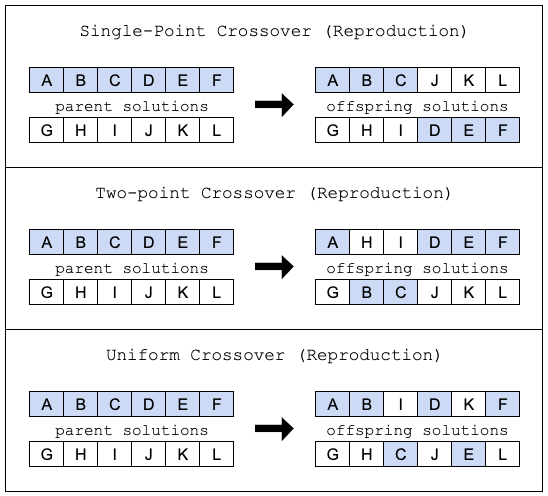


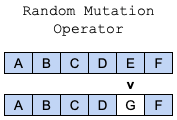

### The Challenges of GAs

- **Getting the selection pressure right.** High selection pressure causes the population to converge prematurely to the local optima. This is mainly controlled by which selection method you use, and your strategy for elitist selection for survival to the next generation. 
- **Loss of diversity can be problematic.** This can be due to high selection pressure or mutation rates that are too low. You can also incorporate diversity directly in the fitness calculation, or treat it as a multiobjective optimisation problem with diversity as a secondary objective.
- **Tuning the GA parameters** (population size, mutation rate) to get good performance can be a trial and error process. If the mutation rate is too high then there won't be any convergence, so use it sparingly. There are adaptive versions of GAs that will change these for you. 
- **Tuning constraint penalty factors** can be a real challenge. Ideally you want an infeasible solution to be only slightly worse than a feasible one so that you can navigate along the boundaries of the feasible region.
- **Computational complexity and speed.** GAs involve evaluating many solutions over many generations. Running time scales exponentially with population size and number of generations. It is important that your code is fast and computationally efficient: e.g. favour `numpy` over  `pandas` for representing your solutions; use more efficient sorting algorithms, etc.


In [3]:
# SIMPLE GA FUNCTION EXAMPLES
# example of simple fitness, crossover, mutation and selection operators
import numpy as np
import random

# decision variables are integers in the range 1 to 15
# fitness objective is to maximise the sum of the elements
solution_1 = np.array([1,2,3])
solution_2 = np.array([4,5,6])
solution_3 = np.array([7,8,9])
solution_4 = np.array([10,11,12])
solution_5 = np.array([2,3,15])
population = [solution_1, solution_2, solution_3, solution_4, solution_5]

# fitness function is sum of elements (maximisation problem)
def simple_fitness(solution: np.array) -> float:
    return np.sum(solution)

# roulette wheel parent selection (not recommended - selection pressure too high)
def simple_selection(population: list) -> np.array:
    # calculate fitness for entire population
    population_fitness = [simple_fitness(p) for p in population]
    # create a probability of selection by dividing total fitness
    selection_probability = population_fitness / sum(population_fitness)
    # create cumulative probabilities per solution
    cumulative_probability = [sum(selection_probability[:i+1]) for i in range(len(selection_probability))]
    # select index with the calculated probabilities 
    rand = random.random()
    selected_index = len([c for c in cumulative_probability if c < rand])
    return population[selected_index]

# one-point crossover
def simple_crossover(parent1: np.array, parent2: np.array) -> (np.array, np.array):
    idx = random.randint(1, len(parent1)-1)
    child1 = np.concatenate((parent1[:idx], parent2[idx:]))
    child2 = np.concatenate((parent2[:idx], parent1[idx:]))
    return child1, child2

# mutate array elements with probability mutation_rate
def simple_mutation(solution: np.array, min_range=1, max_range=15, mutation_rate=0.01) -> np.array:
    mutated = [solution[i] if random.random() < mutation_rate else random.randint(min_range, max_range) for i in range(len(solution))]
    return mutated
    
########################################## TESTS

print("solution 1: " + str(solution_1))
print("solution 1 fitness: " + str(simple_fitness(solution_1)))

parent_1 = simple_selection(population)
parent_2 = parent_1
while np.array_equal(parent_2, parent_1):
    parent_2 = simple_selection(population)
print("parent 1: " + str(parent_1))
print("parent 2: " + str(parent_2))

child_1, child_2 = simple_crossover(parent_1, parent_2)
print("child 1: " + str(child_1))
print("child 2: " + str(child_2))

mutated = child_2
while np.array_equal(mutated, child_2):
    mutated = simple_mutation(child_2)

print("mutated child 2: " + str(mutated))
print("mutated child 2 fitness: " + str(simple_fitness(mutated)))

solution 1: [1 2 3]
solution 1 fitness: 6
parent 1: [1 2 3]
parent 2: [10 11 12]
child 1: [ 1  2 12]
child 2: [10 11  3]
mutated child 2: [6, 12, 1]
mutated child 2 fitness: 19


-----------------------------------------------------------------------------------------------

## Peak Genetic Algorithm Challenge 2022! 
#### An Optimisation Workgroup Initiative

Code your own GA to solve the **Santa's Workshop Elf Staffing Problem** to minimise costs subject to hard and soft constraints, including fairness requirements.

🏆 **Grand Prize for the best performing GA**: _Essentials of Metaheuristics_ book by Sean Luke

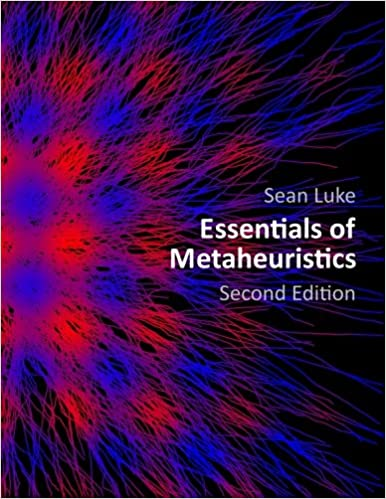

### Competition Rules and Instructions:

- Clone the `ga-challenge-2022` repo and create your own branch named `<your_full_name>`
- Use the `python` code template in `/src` to create your own genetic algorithm to solve the problem below 
- Complete the 4 functions for selection, crossover and mutation marked **# TODO: ADD CODE HERE** in `src/genetic_algorithm_EDIT.py`
- Adjust the optimisation parameters in `src/opt_params_EDIT.py`
- You must be able to run the code using `python src/opt_experiment.py`
- The constraint functions and an objective function have been provided for you! 
- Do not change `src/problem.py` or sections marked **# DO NOT EDIT**
- You may _(very) optionally_ include fancy things like _repair operators, diversity promotion, adaptative parameters,_ and _local search_.
- The optimisation problem parameters and constraint penalty weights have been provided for you. Feel free to adjust GA parameters and code, but **note that you will be judged on the fitness value given by `obj_func_with_penalty()` with the provided penalty weights!**.
- The code must be your own. You can use any software libraries that **aren't optimisation related!**.
- The winning algorithm will have the best average fitness out of 5 x 60 second runs. Computation speed is important!
- Note that the code will be run independently on an isolated machine to calculate performance and ensure that it is comparable across algorithms.
- Don't forget to <span style="font-weight:bold;color:red">push your code to Github</span>
- You have until 16:00 UK time on 16 September to submit the above form, or you will not be eligible for the competition.


## Santa's Workshop Elf Staffing Problem

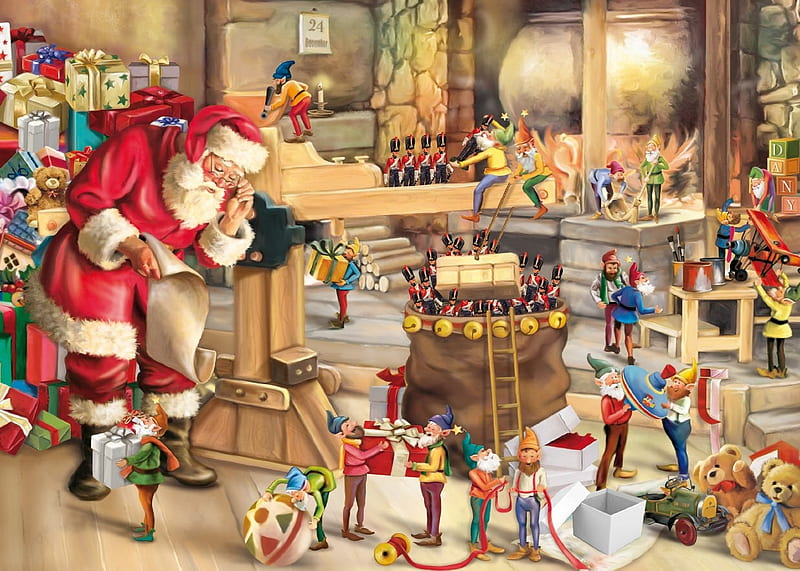

### Problem Overview

There are only 2 weeks left before Xmas and Santa's workshop is buzzing with activity to build all the toys in time to bring Yuletide joy to the 2 billion children worldwide!

Unfortunately for Santa, the <span style="font-weight:bold">Santas Little Workers Union</span> has demanded some drastic changes to employment conditions to increase fairness and improve elf-esteem:
- No individual elf may work more than 48 hours (i.e. 4 12-hour shifts) in a row
- The most hard-working elf must work a maximum of 50% more hours than the least hard-working elf (in total)
- Junior elf wages must be increased from 2 to 3 cookies per hour
- Senior elf wages must be increased from 3 to 4 cookies per hour

#### The Work and the Elves

- There are 500,000,000 toys that still need to be made.  
- There are 200 elves (150 junior and 50 senior) available to be assigned to the remaining 28 shifts before Xmas Day 
- Each senior elf can produce 15,000 toys per hour. Each junior elf can produce 10,000 toys per hour.
- There is only space for 150 elves at a time in Santa's workshop during the first week, and 140 elves during the last week (Santa's enormous toy sack displaces 10 elves)

#### Objectives and Constraints
- Minimise total cookie costs = 3 (sum of junior hours) + 4 (sum of senior hours)
- subject to:
  - Toy production requirements (>= 500,000,000)
  - Week 1 workshop capacity constraints (<= 150)
  - Week 2 workshop capacity constraints (<= 140)
  - Maximum consecutive shifts (<= 4)
  - Maximum ratio of maximum to minimum total hours (<= 1.5)
  

**THE CODE FOR THIS PROBLEM HAS BEEN COMPLETED FOR YOU. YOU ONLY NEED TO WORK ON THE GENETIC ALGORITHM ITSELF.**  
The code below is for analysis only. The problem code lives in `ga-challenge-2022/src/problem.py`


In [258]:
import numpy as np
from numba import njit

# define known problem constants
num_junior_elves = 150
num_senior_elves = 50
num_shifts = 28
hours_per_shift = 12
junior_toys_per_shift = 10000 * 12
senior_toys_per_shift = 15000 * 12
junior_cookie_rate = 3
senior_cookie_rate = 4

shift_workshop_capacities = np.append(np.ones(14)*150, np.ones(14)*140)
max_min_ratio = 1.5
max_consecutive_shifts = 4
num_toys = 500000000

# sample decision variable chromosomes
# 0 indicates an elf is NOT working that shift
# 1 indicates an elf IS working that shift
# decision variable matrix with a row for every elf, and a column for every shift.
# By construction, the first num_junior_elves rows are for junior elves
np.random.seed(2)
random_elf_shift_vars = np.round(np.random.rand(num_junior_elves + num_senior_elves, num_shifts))
all_ones_shift_vars = np.ones((num_junior_elves + num_senior_elves, num_shifts))
all_zeros_shift_vars = np.zeros((num_junior_elves + num_senior_elves, num_shifts))
all_ones_shift_vars_bar_one = np.copy(all_ones_shift_vars)
all_ones_shift_vars_bar_one[0, :] = np.zeros(num_shifts)


# helper function
@njit
def count_consecutive_ones(arr, cols=num_shifts):
    """
    Helper function to calculate number of 1's in each group of consecutive 1's in an individual elf's shift
    @param arr: row of decision matrix representing an individual elf's schedule
    @param cols: the total number of shifts in a single schedule
    @return: array of length int(cols/2) where each element is the number of 1's per group of consecutive 1's
    """
    length = int(cols/2)
    groups_of_ones = np.zeros(length)
    group_idx = 0
    array_idx = 0
    while array_idx < cols:
        if arr[array_idx] == 1:
            ones_count = 1
            if array_idx+1 < cols:
                while arr[array_idx+1] == 1:
                    ones_count += 1
                    if array_idx+2 < cols:
                        array_idx += 1
                    else:
                        break
                groups_of_ones[group_idx] = ones_count
                group_idx += 1
                array_idx += 1
            else:
                if group_idx < length:
                    groups_of_ones[group_idx] = ones_count
                    array_idx += 1
                else:
                    array_idx += 1
        else:
            array_idx += 1
    return groups_of_ones


# constraint functions
def calculate_toy_shortfall(elf_shift_vars,
                            num_junior_elves=num_junior_elves,
                            junior_toys_per_shift=junior_toys_per_shift,
                            senior_toys_per_shift=senior_toys_per_shift,
                            toys_needed=num_toys,
                            calculate_produced=False,
                            ):
    """
    Calculates the total toy shortfall relative to toys_needed
    Addresses constraint: Toy production requirements (>= 500,000,000)
    @param elf_shift_vars: num_elves x num_shifts binary matrix of decision variables
    @param num_junior_elves: the total number of junior elves
    @param junior_toys_per_shift: the number of toys a junior elf can make in a shift
    @param senior_toys_per_shift: the number of toys a senior elf can make in a shift
    @param toys_needed: the total number of toys to be manufactured over the planning horizon
    @param calculate_produced: if True return total num toys produced instead
    @return: shortfall of toys produced versus toys needed for a given solution, or zero if feasible
    """
    junior_toys_produced = np.sum(elf_shift_vars[:num_junior_elves, :] * junior_toys_per_shift)
    senior_toys_produced = np.sum(elf_shift_vars[num_junior_elves:, :] * senior_toys_per_shift)
    if calculate_produced:
        return junior_toys_produced + senior_toys_produced
    else:
        return max(toys_needed - (junior_toys_produced + senior_toys_produced), 0)


def workshop_capacity_violation(elf_shift_vars, capacities=shift_workshop_capacities):
    """
    Addresses constraint:  There is only space for 150 elves at a time in Santa’s workshop during the first week,
    and 140 elves during the last week (Santa’s enormous toy sack displaces 10 elves)
    @param elf_shift_vars: num_elves x num_shifts binary matrix of decision variables
    @param capacities: num_shifts length array holding the workshop capacity per shift
    @return: sum total of workshop capacity violations over all shifts for a given solution, or zero if feasible
    """
    elfs_per_shift = np.sum(elf_shift_vars, axis=0)
    capacity_violations = np.where(elfs_per_shift <= capacities, 0,
                                   elfs_per_shift - capacities)
    return np.sum(capacity_violations)


def consecutive_shift_violation(elf_shift_vars, max_consecutive=max_consecutive_shifts, n_shifts=num_shifts):
    """
    Addresses constraint: No individual elf may work more than 48 hours (i.e. 4 12-hour shifts) in a row
    @param elf_shift_vars: num_elves x num_shifts binary matrix of decision variables
    @param max_consecutive: maximum number of consecutive shifts an elf may work
    @param n_shifts: total number of shifts to schedule
    @return: the sum total of max consecutive shifts violations for a given solution, or zero if feasible
    """
    # count groups of consecutive shifts per elf
    count_groups = np.apply_along_axis(count_consecutive_ones, 1, elf_shift_vars, n_shifts).flatten()
    # filter out groups less than or equal to 4 consecutive shifts
    count_groups = np.where(count_groups <= max_consecutive, 0, count_groups-max_consecutive)
    # sum the total constraint violation
    excess_shifts = np.sum(count_groups)
    return excess_shifts


def elf_max_min_ratio_violation(elf_shift_vars, max_min_ratio=max_min_ratio) -> float:
    """
    Addresses constraint: The most hard-working elf must work a maximum of 50% more hours than the
    least hard-working elf (in total)
    @param elf_shift_vars: num_elves x num_shifts binary matrix of decision variables
    @param max_min_ratio: the maximum ratio of the most number of shifts worked to the least
    @return: violation of max_min_ratio for a given solution, or zero if feasible
    """
    elfs_per_shift = np.sum(elf_shift_vars, axis=1)
    max_shifts = np.max(elfs_per_shift)
    min_shifts = max(np.min(elfs_per_shift), 1)  # prevent division by zero
    return max(0, max_shifts / min_shifts - max_min_ratio)


# problem-specific objective and penalty functions
def calculate_cookie_wages(elf_shift_vars,
                           num_junior_elves=num_junior_elves,
                           junior_cookies_per_hour=junior_cookie_rate,
                           senior_cookies_per_hour=senior_cookie_rate,
                           hours_per_shift=hours_per_shift,
                           ):
    """
    Objective function that calculates the total wages in units of cookies
    Junior elf wages = 3 cookies per hour
    Senior elf wages = 4 cookies per hour
    @param elf_shift_vars: num_elves x num_shifts binary matrix of decision variables
    @param num_junior_elves: the total number of junior elves
    @param junior_cookies_per_hour: junior elf cookie wages rate per hour
    @param senior_cookies_per_hour: senior elf cookie wages rate per hour
    @param hours_per_shift: total number of hours per shift
    @return: sum total of junior and senior elf cookie wages for a given solution
    """
    junior_cookie_wages = np.sum(elf_shift_vars[:num_junior_elves, :] * hours_per_shift * junior_cookies_per_hour)
    senior_cookie_wages = np.sum(elf_shift_vars[num_junior_elves:, :] * hours_per_shift * senior_cookies_per_hour)
    return junior_cookie_wages + senior_cookie_wages


def random_shifts_initialisation(num_elves: int, num_shifts: int, pop_size:int=None):
    """
    Creates a randomised solution or population of solutions for the shift scheduling problem
    @param num_elves: number of rows representing elves
    @param num_shifts: number of columns representing shifts
    @param pop_size: population size for genetic algorithm
    @return: num_elves x num_shifts x pop_size binary matrix of uniformly random solutions
    """
    if pop_size is not None:
        return np.round(np.random.rand(num_elves, num_shifts, pop_size))
    else:
        return np.round(np.random.rand(num_elves, num_shifts))


### Investigate maximum costs & constraint violation ranges to determine constraint penalty weights

In [259]:
# investigate maximum costs and penalty violations to 

print("Max unconstrained toy production")
max_toys = calculate_toy_shortfall(all_ones_shift_vars, calculate_produced=True)
print(max_toys)
print(" ")

print("Maximum cost in cookies:")
max_cost = calculate_cookie_wages(all_ones_shift_vars)
print(max_cost)
print("Approx minimum cost in cookies:")
print(round(num_toys/max_toys*max_cost,2))
cost_diff = round(max_cost - num_toys/max_toys*max_cost,2)
print("Cost difference: " + str(cost_diff))
print(" ")

print("Maximum toy shortfall")
max_toy_shortfall = calculate_toy_shortfall(all_zeros_shift_vars)
print(max_toy_shortfall)
print("Minimum toy shortfall")
print(1)
print(" ")

print("Maximum workshop capacity violation")
max_workshop_violation = workshop_capacity_violation(all_ones_shift_vars)
print(max_workshop_violation)
print("Minimum workshop capacity violation")
print(1)
print(" ")

print("Maximum consecutive shifts violation")
max_consec_shifts = consecutive_shift_violation(all_ones_shift_vars)
print(max_consec_shifts)
print("Minimum consecutive shifts violation")
print(1)
print(" ")

print("Maximum work ratio violation")
max_ratio = elf_max_min_ratio_violation(all_ones_shift_vars_bar_one)
print(max_ratio)
print("Minimum work ratio violation")
print(round(28/18-1.5,3))
print(" ")

print(" ")
print("Initial suggestions for penalty factors (based on rationale of infeasible solution being more expensive than most expensive solution):")
print("Toy shortfall violation: " + str(cost_diff/1+1))
print("Workshop capacity violation: " + str(cost_diff/1+1))
print("Consecutive shifts violation: " + str(cost_diff/1+1))
print("Elf work ratio violation: " + str(round(cost_diff/0.056+1,3)))


Max unconstrained toy production
756000000.0
 
Maximum cost in cookies:
218400.0
Approx minimum cost in cookies:
144444.44
Cost difference: 73955.56
 
Maximum toy shortfall
500000000.0
Minimum toy shortfall
1
 
Maximum workshop capacity violation
1540.0
Minimum workshop capacity violation
1
 
Maximum consecutive shifts violation
4800
Minimum consecutive shifts violation
1
 
Maximum work ratio violation
26.5
Minimum work ratio violation
0.056
 
 
Initial suggestions for penalty factors (based on rationale of infeasible solution being more expensive than most expensive solution):
Toy shortfall violation: 73956.56
Workshop capacity violation: 73956.56
Consecutive shifts violation: 73956.56
Elf work ratio violation: 1320636.0
